In [1]:
%pip install koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [2]:
import koreanize_matplotlib

# 운수좋은날.txt 단어 빈도수 분석

파이썬을 사용하여 `운수좋은날.txt`에서 어떤 단어가 가장 많이 나오는지 분석합니다.

## KoNLPy를 이용한 형태소 분석 (명사 추출)
한국어 자연어 처리 패키지인 `konlpy`를 사용하여 문장에서 '명사'만 정확하게 추출해 분석합니다.
(이를 위해 먼저 `konlpy` 패키지를 설치해야 합니다.)

In [ ]:
!pip install konlpy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
from konlpy.tag import Okt
from collections import Counter

# 형태소 분석기 초기화
okt = Okt()

# 파일 읽기
file_path = "운수좋은날.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

# 명사만 추출
nouns = okt.nouns(text)

# 길이가 1인 단어(예: 것, 수, 등)는 의미가 없는 경우가 많아 제외할 수 있습니다.
filtered_nouns = [noun for noun in nouns if len(noun) >= 2]

# 단어 빈도수 계산
noun_counts = Counter(filtered_nouns)

# 가장 많이 나온 명사 상위 20개 출력
print("--- 상위 20개 명사 (KoNLPy) ---")
for word, count in noun_counts.most_common(20):
    print(f"{word}: {count}번")


--- 상위 20개 명사 (KoNLPy) ---
진수: 32번
혜진: 23번
이혼: 10번
설렁탕: 8번
시간: 6번
오늘: 5번
소리: 5번
도장: 5번
마지막: 5번
머리: 4번
운수: 4번
당신: 4번
수영: 3번
정말: 3번
마음: 3번
웃음: 3번
이제: 3번
목소리: 3번
부탁: 3번
고개: 3번


## 시각화: 막대그래프 및 워드클라우드
위에서 추출한 단어 빈도수를 바탕으로 시각화를 진행합니다. (필요 시 아래 패키지를 설치해주세요.)

In [5]:
!pip install matplotlib wordcloud


Defaulting to user installation because normal site-packages is not writeable


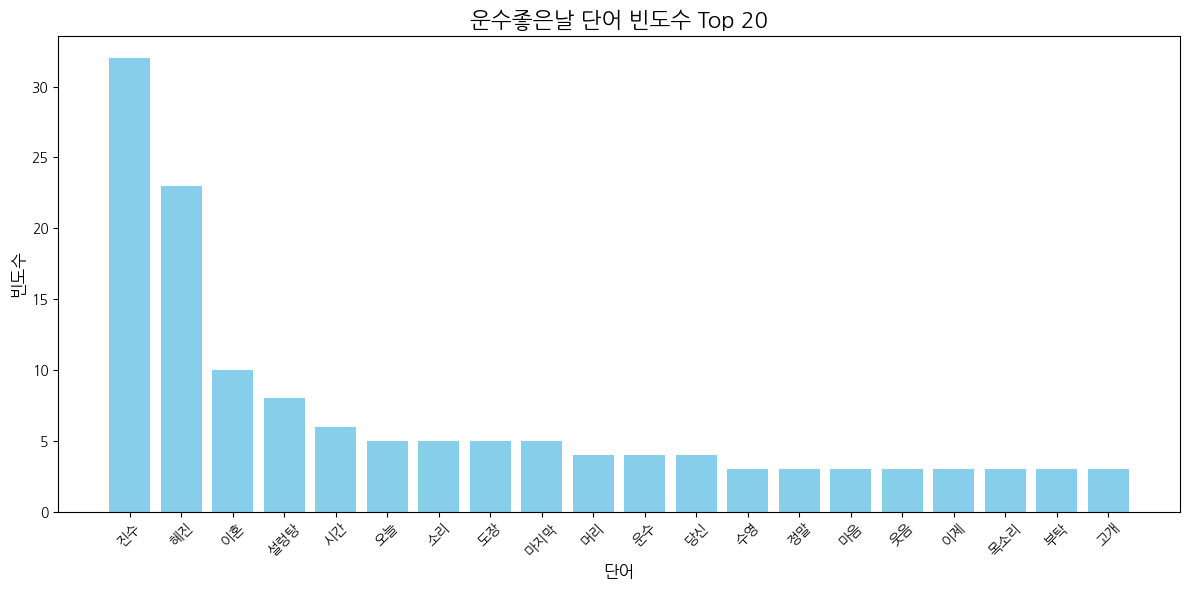

In [6]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 한글 폰트 설정 (리눅스 환경 나눔고딕)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 앞에서 분석한 결과(noun_counts 또는 word_counts)를 사용합니다.
# 여기서는 KoNLPy의 결과인 noun_counts를 사용한다고 가정합니다.
# 만약 KoNLPy 없이 분석하셨다면 `noun_counts`를 `word_counts`로 변경해주세요.
top_words = noun_counts.most_common(20)
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# 1. 막대그래프 그리기
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.title('운수좋은날 단어 빈도수 Top 20', fontsize=16)
plt.xlabel('단어', fontsize=12)
plt.ylabel('빈도수', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


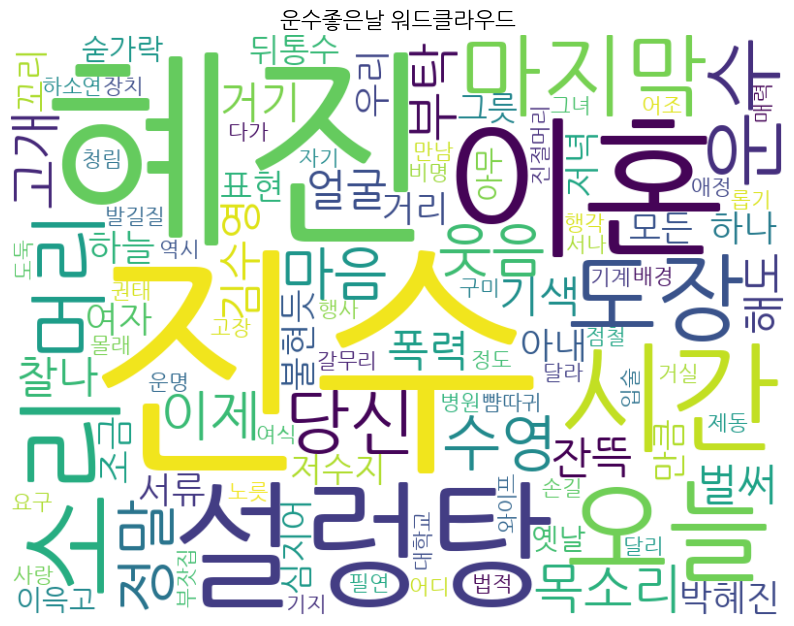

In [7]:
# 2. 워드클라우드 그리기
# 리눅스 시스템의 나눔고딕 폰트 경로를 지정합니다.
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

wordcloud = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=600,
    max_words=100
).generate_from_frequencies(dict(noun_counts))

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('운수좋은날 워드클라우드', fontsize=16)
plt.show()


## 텍스트 마이닝 고도화: 불용어(Stopwords) 제거하기
위의 결과를 보면 '진수', '혜진' 등 등장인물의 이름이 가장 많이 나옵니다. 하지만 이름은 소설의 주인공일 뿐, 소설의 상징적인 '의미'를 파악하는 데에는 큰 도움이 되지 않습니다.
이렇게 분석에 큰 의미가 없는 단어들을 **불용어(Stopwords)**라고 합니다. 불용어를 제거하고 다시 시각화를 해봅시다.

In [8]:
from collections import Counter

# 불용어 리스트 정의 (이름 및 의미 없는 단어)
stop_words = ['진수', '혜진', '수영', '수정', '진수가', '혜진이', '오늘', '진수에게', '정말']

# 불용어가 아닌 단어만 다시 필터링
final_nouns = [word for word in filtered_nouns if word not in stop_words]

# 새로운 빈도수 계산
final_counts = Counter(final_nouns)

print("--- 불용어 제거 후 상위 20개 단어 ---")
for word, count in final_counts.most_common(20):
    print(f"{word}: {count}번")


--- 불용어 제거 후 상위 20개 단어 ---
이혼: 10번
설렁탕: 8번
시간: 6번
소리: 5번
도장: 5번
마지막: 5번
머리: 4번
운수: 4번
당신: 4번
마음: 3번
웃음: 3번
이제: 3번
목소리: 3번
부탁: 3번
고개: 3번
잔뜩: 2번
폭력: 2번
벌써: 2번
기색: 2번
찰나: 2번


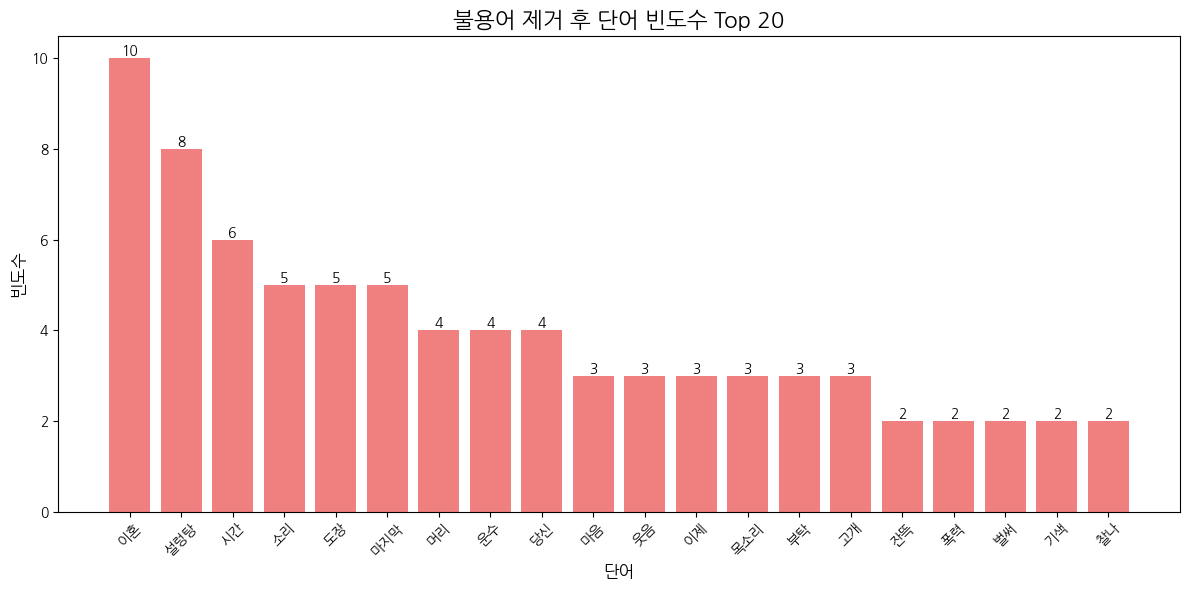

막대그래프가 '막대그래프.png'로 저장되었습니다.


In [9]:
# 1. 불용어 제거 후 막대그래프 다시 그리기 및 저장
top_words_final = final_counts.most_common(20)
words_final = [w[0] for w in top_words_final]
counts_final = [w[1] for w in top_words_final]

plt.figure(figsize=(12, 6))
bars = plt.bar(words_final, counts_final, color='lightcoral')
plt.title('불용어 제거 후 단어 빈도수 Top 20', fontsize=16)
plt.xlabel('단어', fontsize=12)
plt.ylabel('빈도수', fontsize=12)
plt.xticks(rotation=45)

# 막대그래프에 값 추가
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('막대그래프.png', dpi=300)
plt.show()
print("막대그래프가 '막대그래프.png'로 저장되었습니다.")

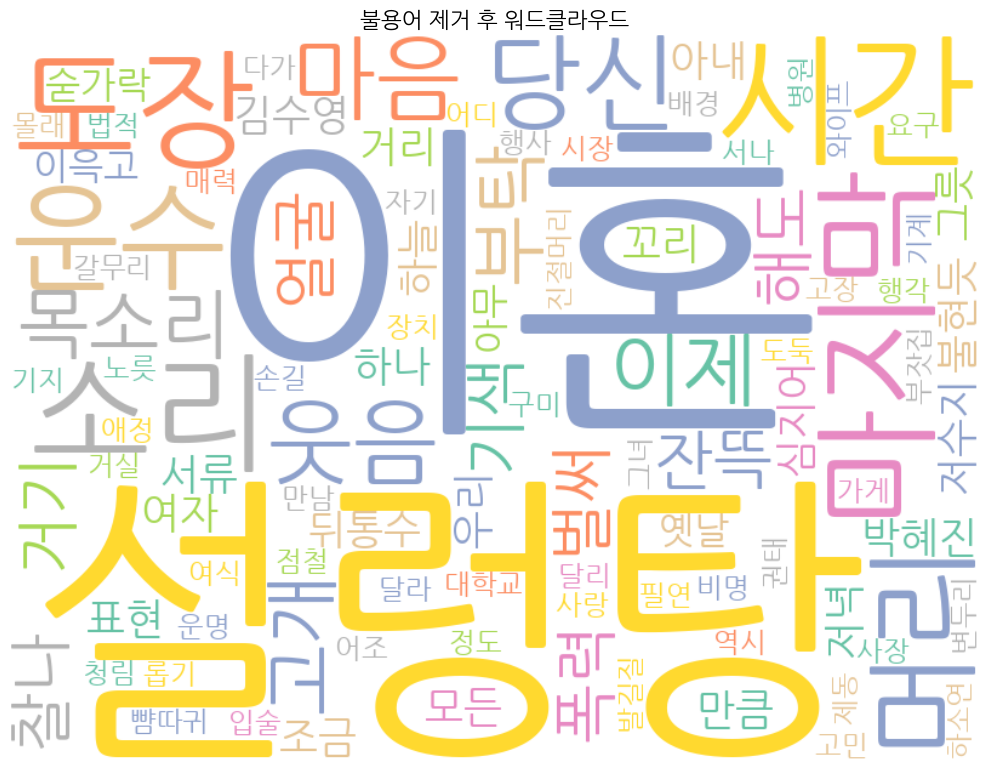

워드클라우드가 '워드클라우드.png'로 저장되었습니다.


In [10]:
# 2. 불용어 제거 후 워드클라우드 다시 그리기 및 저장
wordcloud_final = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800,
    height=600,
    max_words=100,
    colormap='Set2'
).generate_from_frequencies(dict(final_counts))

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud_final, interpolation='bilinear')
plt.axis('off')
plt.title('불용어 제거 후 워드클라우드', fontsize=16)
plt.tight_layout()
plt.savefig('워드클라우드.png', dpi=300)
plt.show()
print("워드클라우드가 '워드클라우드.png'로 저장되었습니다.")

## 엑셀 파일로 결과 저장
위에서 구한 `final_counts`의 상위 20개 결과를 데이터프레임으로 변환하여 엑셀 파일로 저장합니다.

In [11]:
!pip install pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [12]:
import pandas as pd

# 상위 20개 단어 추출
top_20 = final_counts.most_common(20)

# 데이터프레임 생성
df = pd.DataFrame(top_20, columns=["단어", "빈도수"])

# 엑셀 파일로 저장
file_name = "운수좋은날_단어빈도수.xlsx"
df.to_excel(file_name, index=False)

print(f"결과가 {file_name} 파일로 성공적으로 저장되었습니다.")
df.head()


결과가 운수좋은날_단어빈도수.xlsx 파일로 성공적으로 저장되었습니다.


,단어,빈도수
0,이혼,10
1,설렁탕,8
2,시간,6
3,소리,5
4,도장,5
